# PROJET FIL ROUGE
##### Modèle de Machine Learning sur les Jeux Olympiques de 2028 à Los Angeles 

### **NETTOYAGE ET PRÉPARATION DES DONNÉES**

##### IMPORT DE L'ENVIRONNEMENT DE TRAVAIL

In [1030]:
import pandas as pd

df = pd.read_csv("olympics_dataset.csv")

##### VISUALISATION DES DONNÉES

In [1031]:
df.head()

,player_id,Name,Sex,Team,NOC,Year,Season,City,Sport,Event,Medal
0,0,A Dijiang,M,China,CHN,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No medal
1,1,A Lamusi,M,China,CHN,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No medal
2,2,Gunnar Aaby,M,Denmark,DEN,1920,Summer,Antwerpen,Football,Football Men's Football,No medal
3,3,Edgar Aabye,M,Denmark/Sweden,DEN,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,26,Cornelia (-strannood),F,Netherlands,NED,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,No medal


In [1032]:
df.shape

(252565, 11)

In [1033]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252565 entries, 0 to 252564
Data columns (total 11 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   player_id  252565 non-null  int64 
 1   Name       252565 non-null  object
 2   Sex        252565 non-null  object
 3   Team       252565 non-null  object
 4   NOC        252565 non-null  object
 5   Year       252565 non-null  int64 
 6   Season     252565 non-null  object
 7   City       252565 non-null  object
 8   Sport      252565 non-null  object
 9   Event      252565 non-null  object
 10  Medal      252565 non-null  object
dtypes: int64(2), object(9)
memory usage: 21.2+ MB


##### VÉRIFICATION DE LA QUALITÉ DES DONNÉES 

In [1034]:
df.isna().sum() # vérification des valeurs nulles dans le dataset 

player_id    0
Name         0
Sex          0
Team         0
NOC          0
Year         0
Season       0
City         0
Sport        0
Event        0
Medal        0
dtype: int64

In [1035]:
df.duplicated().sum() # vérification des doublons dans le dataset

0

In [1036]:
df['Season'].unique() # vérification des colonnes à potentiellement supprimer 

array(['Summer'], dtype=object)

In [1037]:
df = df.drop(['Season'], axis=1) # suppression de la colonne Season car 1 seule valeur unique

In [1038]:
df["NOC"].nunique() # vérification de la pertinence de la colonne par rapport à Team


234

In [1039]:
df["Team"].nunique() # vérification de la pertinence de la colonne par rapport à NOC

1193

##### VALEURS ABERRANTES 

In [1040]:
df.head()

,player_id,Name,Sex,Team,NOC,Year,City,Sport,Event,Medal
0,0,A Dijiang,M,China,CHN,1992,Barcelona,Basketball,Basketball Men's Basketball,No medal
1,1,A Lamusi,M,China,CHN,2012,London,Judo,Judo Men's Extra-Lightweight,No medal
2,2,Gunnar Aaby,M,Denmark,DEN,1920,Antwerpen,Football,Football Men's Football,No medal
3,3,Edgar Aabye,M,Denmark/Sweden,DEN,1900,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,26,Cornelia (-strannood),F,Netherlands,NED,1932,Los Angeles,Athletics,Athletics Women's 100 metres,No medal


Year    Axes(0.125,0.747241;0.110714x0.132759)
dtype: object

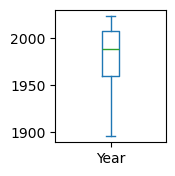

In [1041]:
# Visualisation de la seule colonne numérique

df['Year'].plot(
    kind="box",
    subplots=True,
    layout=(5, 6),
    figsize=(10, 10)
)

##### ENCODAGE DES DONNÉES (Sex, Medal)

In [1042]:
df['Sex'].unique()

array(['M', 'F'], dtype=object)

In [1043]:
df["Sex_encoded"] = df["Sex"].map({"M": 1, "F": 0}) # encodage de Sex pour faciliter la création des champs 

In [1044]:
df["Medal"].unique()

array(['No medal', 'Gold', 'Bronze', 'Silver'], dtype=object)

In [1045]:
df = df.copy() # pour anticiper l'ajout des features dans la prochaine partie 

In [1046]:
# Normalisation de Medal

df["Medal"] = (
    df["Medal"]
    .astype(str)
    .str.strip()
    .str.lower()
)

In [1047]:
# Encodage réaliste des médailles

df["Medal_score"] = df["Medal"].map({
    "no medal": 0,
    "bronze": 1,
    "silver": 2,
    "gold": 3
})

##### CRÉATION DE NOUVEAUX CHAMPS 

1. FEATURES ATHLÈTES

In [1048]:
# Indicateur binaire : l’athlète a-t-il gagné une médaille ?
df["has_medal"] = (df["Medal_score"] > 0).astype(int)

In [1049]:
# Durée de carrière olympique (première → dernière participation)

df["histo_athlete_years"] = (
    df.groupby("Name")["Year"]
      .transform(lambda x: x.max() - x.min())
)

In [1050]:
# Nombre total de participations par athlète

df["particip_athlete"] = (
    df.groupby("Name")["Year"]
      .transform("count")
)

In [1051]:
# Nombre d’équipes distinctes par athlète, pays, année

df["nb_team"] = (
    df.groupby(["Name", "NOC", "Year"])["Team"]
      .transform("nunique")
)

In [1052]:
# Nombre d’events par athlète et par année

df["event_athlete"] = (
    df.groupby(["player_id", "Year"])["Event"]
      .transform("nunique")
)

In [1053]:
# Nombre de sports par athlète et par année

df["sport_athlete"] = (
    df.groupby(["player_id", "Year"])["Sport"]
      .transform("nunique")
)

In [1054]:
# Score médaille par athlète et année

df["medal_score_athlete_year"] = (
    df.groupby(["player_id", "Year"])["Medal_score"]
      .transform("sum")
)

In [1055]:
# Score médaille total par athlète

df["medal_score_athlete_total"] = (
    df.groupby("player_id")["Medal_score"]
      .transform("sum")
)

In [1056]:
# Nombre de médailles par athlète et année (count)

df["medal_athlete"] = (
    df.groupby(["player_id", "Year"])["has_medal"]
      .transform("sum")
)

In [1057]:
# Nombre total de médailles par athlète

df["nb_medal_athlete"] = (
    df.groupby("player_id")["has_medal"]
      .transform("sum")
)

2. FEATURES PAYS (NOC)

In [1058]:
# Durée historique du pays

df["histo_country_years"] = (
    df.groupby("NOC")["Year"]
      .transform(lambda x: x.max() - x.min())
)

In [1059]:
# Nombre total de participations par pays (années distinctes)

df["particip_pays"] = (
    df.groupby("NOC")["Year"]
      .transform("nunique")
)

In [1060]:
# Nombre d’athlètes distincts par pays et année

df["nb_athlete_country"] = (
    df.groupby(["NOC", "Year"])["Name"]
      .transform("nunique")
)

In [1061]:
# Nombre d’équipes distinctes par pays et année

df["nb_team_country"] = (
    df.groupby(["NOC", "Year"])["Team"]
      .transform("nunique")
)

In [1062]:
# Nombre d’events par pays et année

df["event_country"] = (
    df.groupby(["NOC", "Year"])["Event"]
      .transform("nunique")
)

In [1063]:
# Nombre de sports par pays et année

df["sport_country"] = (
    df.groupby(["NOC", "Year"])["Sport"]
      .transform("nunique")
)

In [1064]:
# Nombre total de sports distincts par pays

df["nb_sport_country"] = (
    df.groupby("NOC")["Sport"]
      .transform("nunique")
)

In [1065]:
# Score médaille par pays et année

df["medal_score_country_year"] = (
    df.groupby(["NOC", "Year"])["Medal_score"]
      .transform("sum")
)

In [1066]:
# Score médaille total par pays

df["medal_score_country_total"] = (
    df.groupby("NOC")["Medal_score"]
      .transform("sum")
)

In [1067]:
# Nombre de médailles par pays et année

df["medal_country"] = (
    df.groupby(["NOC", "Year"])["has_medal"]
      .transform("sum")
)

In [1068]:
# Nombre total de médailles par pays

df["nb_medal_country"] = (
    df.groupby("NOC")["has_medal"]
      .transform("sum")
)

3. FEATURES TEAM

In [1069]:
# Participation par team / event / année

df["particip_team_event"] = (
    df.groupby(["Team", "Event", "Year"])["player_id"]
      .transform("nunique")
)

In [1070]:
# Nombre d’events par team et année

df["event_team"] = (
    df.groupby(["Team", "Year"])["Event"]
      .transform("nunique")
)

4. FEATURES EVENT

In [1071]:
# Participation par pays / event / année

df["particip_country_event"] = (
    df.groupby(["NOC", "Event", "Year"])["player_id"]
      .transform("nunique")
)

In [1072]:
# Participation par athlète / event / année

df["particip_athlete_event"] = (
    df.groupby(["player_id", "Event", "Year"])["Event"]
      .transform("count")
)

5. PARTIE HÔTE

In [1073]:
host_cities = {
    1896: ("GRE", "Athens"),
    1900: ("FRA", "Paris"),
    1904: ("USA", "St. Louis"),
    1908: ("GBR", "London"),
    1912: ("SWE", "Stockholm"),
    1920: ("BEL", "Antwerpen"),
    1924: ("FRA", "Paris"),
    1928: ("NED", "Amsterdam"),
    1932: ("USA", "Los Angeles"),
    1936: ("GER", "Berlin"),
    1948: ("GBR", "London"),
    1952: ("FIN", "Helsinki"),
    1956: ("AUS", "Melbourne"),
    1960: ("ITA", "Rome"),
    1964: ("JPN", "Tokyo"),
    1968: ("MEX", "Mexico City"),
    1972: ("GER", "Munich"),
    1976: ("CAN", "Montreal"),
    1980: ("URS", "Moscow"),
    1984: ("USA", "Los Angeles"),
    1988: ("KOR", "Seoul"),
    1992: ("ESP", "Barcelona"),
    1996: ("USA", "Atlanta"),
    2000: ("AUS", "Sydney"),
    2004: ("GRE", "Athens"),
    2008: ("CHN", "Beijing"),
    2012: ("GBR", "London"),
    2016: ("BRA", "Rio de Janeiro"),
    2020: ("JPN", "Tokyo"),
    2024: ("FRA", "Paris"),
}

In [1074]:
host_df = pd.DataFrame.from_dict(
    host_cities,
    orient="index",
    columns=["host_NOC", "host_city"]
)
host_df.index.name = "Year"

df = df.merge(host_df, on="Year", how="left")

df["is_host_country"] = (df["NOC"] == df["host_NOC"]).astype(int)

6. FILTRE FINAL : conserver des athlètes potentiellement toujours en activité

In [1075]:
# Calculer l’année de première participation de chaque athlète

df["first_year_athlete"] = df.groupby("Name")["Year"].transform("min")

In [1076]:
# Calculer l’ancienneté de l’athlète à la date de la ligne

df["experience_years"] = df["Year"] - df["first_year_athlete"]

In [1077]:
# Créer un champ pour identifier les athlètes encore “récents”

df["recent_athlete"] = (df["experience_years"] <= 20).astype(int)

7. FILTRE FINAL : HISTORIQUE JO / EXPÉRIENCE ATHLÈTE 

In [1078]:
# FILTRE FINAL : après 1960 / athlète dont l'expérience est < 20 ans

df = df[
    (df["Year"] > 1960) &
    (df["recent_athlete"] == 1)
].reset_index(drop=True)

##### VÉRIFICATION DES CHAMPS CRÉÉS

In [1079]:
print(df.shape)
print(df_final.columns)

(185212, 43)
Index(['player_id', 'Name', 'Sex', 'Team', 'NOC', 'Year', 'City', 'Sport',
       'Event', 'Medal', 'Sex_encoded', 'Medal_score', 'has_medal',
       'histo_athlete_years', 'particip_athlete', 'nb_team', 'event_athlete',
       'sport_athlete', 'medal_score_athlete_year',
       'medal_score_athlete_total', 'medal_athlete', 'nb_medal_athlete',
       'old_athlete', 'histo_country_years', 'particip_pays',
       'nb_athlete_country', 'nb_team_country', 'event_country',
       'sport_country', 'nb_sport_country', 'medal_score_country_year',
       'medal_score_country_total', 'medal_country', 'nb_medal_country',
       'particip_team_event', 'event_team', 'particip_country_event',
       'particip_athlete_event', 'host_NOC', 'host_city', 'is_host_country',
       'first_year_athlete', 'experience_years', 'recent_athlete'],
      dtype='object')


In [1080]:
df.head()

,player_id,Name,Sex,Team,NOC,Year,City,Sport,Event,Medal,...,particip_team_event,event_team,particip_country_event,particip_athlete_event,host_NOC,host_city,is_host_country,first_year_athlete,experience_years,recent_athlete
0,0,A Dijiang,M,China,CHN,1992,Barcelona,Basketball,Basketball Men's Basketball,no medal,...,12,140,12,1,ESP,Barcelona,0,1992,0,1
1,1,A Lamusi,M,China,CHN,2012,London,Judo,Judo Men's Extra-Lightweight,no medal,...,1,202,1,1,GBR,London,0,2012,0,1
2,31,Jyri Aalto,M,Finland,FIN,2000,Sydney,Badminton,Badminton Men's Singles,no medal,...,1,64,1,1,AUS,Sydney,0,2000,0,1
3,32,Minna Aalto,F,Finland,FIN,1996,Atlanta,Sailing,Sailing Women's Windsurfer,no medal,...,1,74,1,1,USA,Atlanta,0,1996,0,1
4,33,Minna Aalto,F,Finland,FIN,2000,Sydney,Sailing,Sailing Women's Windsurfer,no medal,...,1,64,1,1,AUS,Sydney,0,1996,4,1


In [1081]:
df.isna().sum() # vérification des valeurs nulles dans le dataset 

player_id                    0
Name                         0
Sex                          0
Team                         0
NOC                          0
Year                         0
City                         0
Sport                        0
Event                        0
Medal                        0
Sex_encoded                  0
Medal_score                  0
has_medal                    0
histo_athlete_years          0
particip_athlete             0
nb_team                      0
event_athlete                0
sport_athlete                0
medal_score_athlete_year     0
medal_score_athlete_total    0
medal_athlete                0
nb_medal_athlete             0
histo_country_years          0
particip_pays                0
nb_athlete_country           0
nb_team_country              0
event_country                0
sport_country                0
nb_sport_country             0
medal_score_country_year     0
medal_score_country_total    0
medal_country                0
nb_medal

##### VIF : GESTION DES FEATURES REDONDANTES (détecter la multicolinéarité entre les variables quantitatives)

In [1082]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF

In [ ]:
# Sélection des colonnes et suppression feature par feature selon les résultats du VIF

cols_vif = [
    'Year', 'Medal_score', 'has_medal', 'histo_athlete_years', 'particip_athlete', 'nb_team', 'event_athlete',
    'sport_athlete', 'medal_score_athlete_year', 'medal_score_athlete_total', 'nb_medal_athlete',
    'histo_country_years', 'particip_pays','nb_athlete_country', 'nb_team_country', 'event_country',
    'sport_country', 'nb_sport_country', 'medal_score_country_year', 'medal_score_country_total', 
    'event_team', 'particip_country_event', 'particip_athlete_event', 'is_host_country', 'recent_athlete'
]

# Colonnes supprimées : 'first_year_athlete', 'experience_years', 'nb_medal_country', 'particip_team_event', 'medal_athlete', 'medal_country'

In [1120]:
X = df[cols_vif]

In [1121]:
# Calcul des VIF  

vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [VIF(X.values, i) for i in range(X.shape[1])]
vif["Precision"] = [1 - 1/VIF(X.values, i) for i in range(X.shape[1])]

vif.sort_values("VIF", ascending=False)


,feature,VIF,Precision
15,event_country,51.258718,0.980491
9,medal_score_athlete_total,45.866708,0.978198
1,Medal_score,42.128817,0.976263
10,nb_medal_athlete,41.143501,0.975695
2,has_medal,38.075477,0.973736
13,nb_athlete_country,35.054035,0.971473
20,event_team,29.269996,0.965835
8,medal_score_athlete_year,19.328371,0.948263
16,sport_country,12.199461,0.918029
17,nb_sport_country,8.057194,0.875887


In [1130]:
cols_select = [
    'Name', 'Sex', 'Team', 'NOC', 'Year', 'City', 'Sport', 'Event', 'Medal', 'Sex_encoded', 'host_NOC', 'host_city', 
    'Medal_score', 'has_medal', 'histo_athlete_years', 'particip_athlete', 'nb_team', 'event_athlete',
    'sport_athlete', 'medal_score_athlete_year', 'medal_score_athlete_total', 'nb_medal_athlete',
    'histo_country_years', 'particip_pays','nb_athlete_country', 'nb_team_country', 'event_country',
    'sport_country', 'nb_sport_country', 'medal_score_country_year', 'medal_score_country_total', 
    'event_team', 'particip_country_event', 'particip_athlete_event', 'is_host_country', 'recent_athlete'
]

df_final = df[cols_select].copy()     # Création d'un df propre avec seulement les features nécessaires et non redondantes

### **ANALYSE UNIVARIÉE : Phase CRISP-DM 2 - Compréhension des Données**


##### IMPORT DE L'ENVIRONNEMENT

In [1126]:
import numpy as np  #calculS scientifiqueS
import seaborn as sns #visualiser avec des syntaxes simples
import matplotlib.pyplot as plt #visualiser
import sklearn as skl #Creer des modeles de machine learning (pour ce cours, on verra PCA et KMEANS)
from IPython.display import display, Markdown   #afficher
import scipy
import warnings
warnings.filterwarnings('ignore')

##### PREMIÈRES OBSERVATIONS

AXES À INSPECTER : 
- Est-ce que certains pays ont plus de médailles ?
- Est-ce que certains athlètes ont plus de médailles ?
- Est-ce que certains sports ont plus d'athlètes représentés ? 
- Est-ce que certains 

In [1131]:
# Visualisation statistique du dataset générale

df_final.describe() 

,Year,Sex_encoded,Medal_score,has_medal,histo_athlete_years,particip_athlete,nb_team,event_athlete,sport_athlete,medal_score_athlete_year,...,event_country,sport_country,nb_sport_country,medal_score_country_year,medal_score_country_total,event_team,particip_country_event,particip_athlete_event,is_host_country,recent_athlete
count,185212.000000,185212.000000,185212.000000,185212.000000,185212.000000,185212.000000,185212.000000,185212.000000,185212.0,185212.000000,...,185212.000000,185212.000000,185212.000000,185212.000000,185212.000000,185212.000000,185212.000000,185212.0,185212.000000,185212.0
mean,1997.636978,0.635094,0.289069,0.145639,3.956482,3.598698,1.005631,1.078559,1.0,0.307404,...,120.474321,20.531855,41.697833,124.477447,2097.617719,118.503569,5.887702,1.0,0.050812,1.0
std,17.856540,0.481405,0.767032,0.352744,5.438307,3.741378,0.076119,0.579562,0.0,0.832095,...,72.350702,9.760382,16.033418,165.495508,2863.909517,72.164913,11.551681,0.0,0.219614,0.0
min,1964.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.0,0.000000,...,1.000000,1.000000,2.000000,0.000000,0.000000,1.000000,1.000000,1.0,0.000000,1.0
25%,1984.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.0,0.000000,...,58.000000,14.000000,30.000000,12.000000,236.000000,56.000000,1.000000,1.0,0.000000,1.0
50%,2000.000000,1.000000,0.000000,0.000000,4.000000,2.000000,1.000000,1.000000,1.0,0.000000,...,116.000000,20.000000,43.000000,61.000000,1240.000000,115.000000,3.000000,1.0,0.000000,1.0
75%,2012.000000,1.000000,0.000000,0.000000,8.000000,4.000000,1.000000,1.000000,1.0,0.000000,...,182.000000,27.000000,56.000000,163.000000,2569.000000,180.000000,6.000000,1.0,0.000000,1.0
max,2024.000000,1.000000,3.000000,1.000000,76.000000,38.000000,3.000000,9.000000,1.0,13.000000,...,270.000000,47.000000,67.000000,945.000000,12592.000000,265.000000,122.000000,1.0,1.000000,1.0


In [1132]:
df_final.shape

(185212, 36)

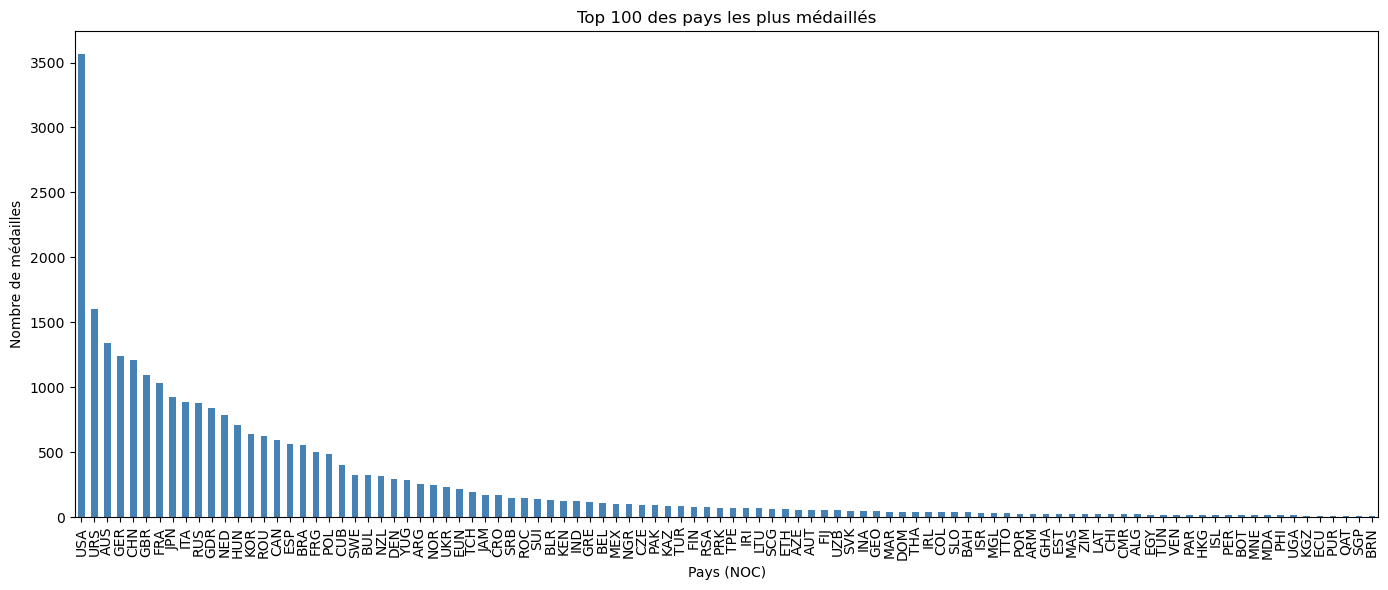

In [1133]:
# distribution globale des médailles par PAYS avec limitation des 100 premiers pays 

medals_by_country = (
    df_final.groupby("NOC")["has_medal"]
      .sum()
      .sort_values(ascending=False)
      .head(100)  
)

plt.figure(figsize=(14,6))
medals_by_country.plot(kind="bar", color="steelblue")
plt.title("Top 100 des pays les plus médaillés")
plt.xlabel("Pays (NOC)")
plt.ylabel("Nombre de médailles")
plt.tight_layout()
plt.show()


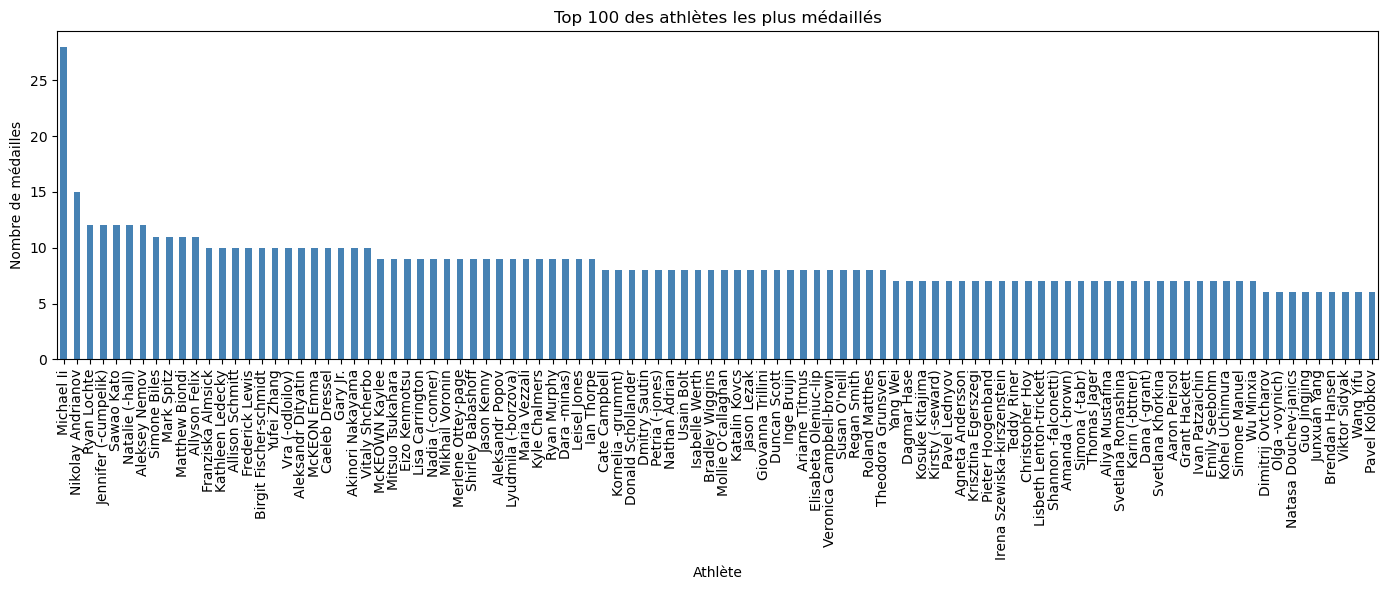

In [1134]:
# distribution globale des médailles par ATHLÈTE avec limitation des 100 premiers athlètes 

medals_by_country = (
    df_final.groupby("Name")["has_medal"]
      .sum()
      .sort_values(ascending=False)
      .head(100)  
)

plt.figure(figsize=(14,6))
medals_by_country.plot(kind="bar", color="steelblue")
plt.title("Top 100 des athlètes les plus médaillés")
plt.xlabel("Athlète")
plt.ylabel("Nombre de médailles")
plt.tight_layout()
plt.show()

<Axes: ylabel='count'>

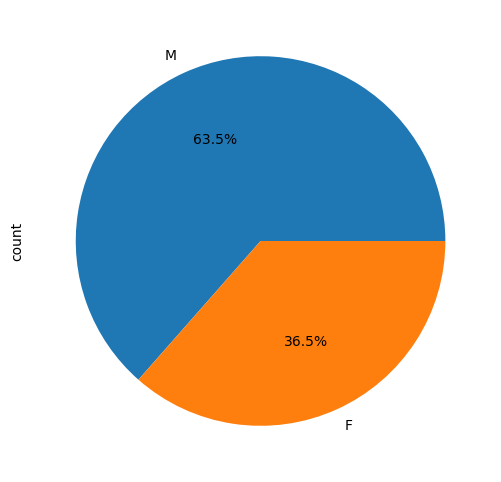

In [1135]:
df_final.Sex.value_counts().plot(kind="pie",figsize=(6,6), autopct='%1.1f%%')

In [ ]:
medal=df.price
# Define price categories for the pie chart
price_categories = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
price_bins = [0, 1000, 3000, 5000, 10000, prices.max()]
price_category_counts = pd.cut(prices, bins=price_bins, labels=price_categories).value_counts()

# Calculate Lorenz curve data
sorted_prices = np.sort(prices)
cumulative_prices = np.cumsum(sorted_prices) / sorted_prices.sum()
lorenz_x = np.linspace(0, 1, len(cumulative_prices))

# Creating subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
fig.tight_layout(pad=6.0)

# 1. Histogram
axes[0, 0].hist(prices, bins=50, color='blue', alpha=0.7)
axes[0, 0].set_title("Histogram of Diamond Prices")
axes[0, 0].set_xlabel("Price")
axes[0, 0].set_ylabel("Frequency")

# 2. Boxplot
axes[0, 1].boxplot(prices, vert=False)
axes[0, 1].set_title("Boxplot of Diamond Prices")
axes[0, 1].set_xlabel("Price")

# 3. Density Plot
prices.plot(kind='density', ax=axes[1, 0], title="Density Plot of Diamond Prices", color='orange')
axes[1, 0].set_xlabel("Price")

# 4. Pie Chart of Price Categories
axes[1, 1].pie(price_category_counts, labels=price_categories, autopct='%1.1f%%', colors=plt.cm.tab10.colors)
axes[1, 1].set_title("Pie Chart of Price Categories")

# 5. Lorenz Curve
axes[2, 0].plot(lorenz_x, cumulative_prices, label="Lorenz Curve", color="green")
axes[2, 0].plot([0, 1], [0, 1], linestyle="--", color="red", label="Equality Line")
axes[2, 0].set_title("Lorenz Curve of Diamond Prices")
axes[2, 0].set_xlabel("Cumulative Share of Diamonds")
axes[2, 0].set_ylabel("Cumulative Share of Prices")
axes[2, 0].legend()

# 6. Bar Plot of Average Price by Color (Reused as placeholder)
avg_price_by_cut = data.groupby('cut')['price'].mean().sort_index()

avg_price_by_cut.plot(kind='bar', ax=axes[2, 1], color='purple', alpha=0.7)
axes[2, 1].set_title("Average Diamond Price by cut")
axes[2, 1].set_xlabel("cut")
axes[2, 1].set_ylabel("Average Price")

plt.show()

### **ANALYSE BIVARIÉE**

### **ANALYSE MULTIVARIÉE**

### **CONSTRUCTION DU MODÈLE DE MACHINE LEARNING**